# Transfer Learning with ResNet50 + LIME - Part 3

**Author:** Kodanda Challa  
**Student ID:** 25727  
**Date:** 2026

## Project Overview

This notebook implements a **production-ready deep learning pipeline** for brain tumor classification using:

1. **Transfer Learning**: Pre-trained ResNet50 from ImageNet
2. **Explainability**: LIME for model interpretability

## 1. Environment Setup

In [1]:
import os
import time
import pickle
import warnings
import random
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from lime import lime_image
from skimage.segmentation import mark_boundaries

warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

✓ All libraries imported successfully
TensorFlow version: 2.21.0
GPU Available: False


## 2. Configuration & Hyperparameters

In [2]:
PROGRAM_START = time.perf_counter()

# Dataset Configuration
DATASET_PATH = "Dataset_MRI"
TRAIN_DIR = os.path.join(DATASET_PATH, 'Training')
TEST_DIR = os.path.join(DATASET_PATH, 'Testing')
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASSES)

# Image Processing
IMG_SIZE = 224
IMG_CHANNELS = 3
SUPPORTED_FORMATS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp')

# Training Configuration
BATCH_SIZE = 32
EPOCHS = 20
VALIDATION_SPLIT = 0.2
INITIAL_LEARNING_RATE = 0.001

# Callbacks
EARLY_STOPPING_MONITOR = 'val_loss'
EARLY_STOPPING_PATIENCE = 5
LR_REDUCTION_FACTOR = 0.3
LR_REDUCTION_PATIENCE = 2

# Model Checkpoint
BEST_MODEL_PATH = 'best_resnet50_model.h5'
LABEL_ENCODER_PATH = 'label_encoder.pkl'
FINAL_MODEL_PATH = 'brain_tumor_classifier_resnet50.h5'

# LIME Configuration
LIME_NUM_SAMPLES = 500
LIME_NUM_FEATURES = 10

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Configuration loaded")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}x{IMG_CHANNELS}")
print(f"Classes: {NUM_CLASSES} - {', '.join(CLASSES)}")

✓ Configuration loaded
Image size: 224x224x3
Classes: 4 - glioma, meningioma, notumor, pituitary


## 3. Data Loading & Preprocessing

In [3]:
def build_dataframe(data_dir, classes, supported_formats):
    """Build DataFrame with file paths and labels."""
    rows = []
    for class_name in classes:
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            print(f"Warning: Directory not found - {class_dir}")
            continue
        
        for filename in os.listdir(class_dir):
            if filename.lower().endswith(supported_formats):
                filepath = os.path.join(class_dir, filename)
                rows.append({'filepath': filepath, 'label': class_name})
    
    return pd.DataFrame(rows)


print("Building dataset indices...")
train_df = build_dataframe(TRAIN_DIR, CLASSES, SUPPORTED_FORMATS)
test_df = build_dataframe(TEST_DIR, CLASSES, SUPPORTED_FORMATS)

print(f"✓ Dataset indices built")
print(f"Training set: {len(train_df)} images")
print(f"Testing set: {len(test_df)} images")
print(f"\nClass Distribution (Training):")
for class_name in CLASSES:
    count = len(train_df[train_df['label'] == class_name])
    pct = (count / len(train_df)) * 100
    print(f"  {class_name:12s}: {count:4d} ({pct:5.1f}%)")

Building dataset indices...
✓ Dataset indices built
Training set: 5600 images
Testing set: 1600 images

Class Distribution (Training):
  glioma      : 1400 ( 25.0%)
  meningioma  : 1400 ( 25.0%)
  notumor     : 1400 ( 25.0%)
  pituitary   : 1400 ( 25.0%)


## 4. Image Loading & Preprocessing Function

In [4]:
def load_images(df, img_size=224, preprocess_fn=None):
    """Load and preprocess images from file paths."""
    images = []
    labels = []
    failed_images = []
    
    for idx, (_, row) in enumerate(df.iterrows()):
        try:
            filepath = row['filepath']
            img = cv2.imread(filepath, cv2.IMREAD_UNCHANGED)
            
            if img is None:
                failed_images.append(filepath)
                continue
            
            # Handle color formats
            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            elif img.shape[2] == 4:
                img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)
            elif img.shape[2] == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
            img = img.astype('float32')
            
            if preprocess_fn is not None:
                img = preprocess_fn(img)
            else:
                img = img / 255.0
            
            images.append(img)
            labels.append(row['label'])
        
        except Exception as e:
            failed_images.append(filepath)
    
    if failed_images:
        print(f"Warning: Failed to load {len(failed_images)} images")
    
    return np.array(images), np.array(labels)


print("Loading training data...")
X_train, y_train_raw = load_images(train_df, IMG_SIZE, preprocess_fn=preprocess_input)
print(f"Training data shape: {X_train.shape}")

print("\nLoading testing data...")
X_test, y_test_raw = load_images(test_df, IMG_SIZE, preprocess_fn=preprocess_input)
print(f"Testing data shape: {X_test.shape}")

print(f"\n✓ Data loading complete")

Loading training data...
Training data shape: (5600, 224, 224, 3)

Loading testing data...
Testing data shape: (1600, 224, 224, 3)

✓ Data loading complete


## 5. Label Encoding

In [5]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

y_train_categorical = to_categorical(y_train, NUM_CLASSES)
y_test_categorical = to_categorical(y_test, NUM_CLASSES)

print("✓ Labels encoded")
print("\nLabel Mapping:")
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name:12s} → {idx}")

✓ Labels encoded

Label Mapping:
  glioma       → 0
  meningioma   → 1
  notumor      → 2
  pituitary    → 3


## 6. Build ResNet50 Transfer Learning Model

In [6]:
def build_resnet50_model(num_classes, img_size=224, freeze_base=True):
    """Build ResNet50 transfer learning model."""
    print("Building ResNet50 Transfer Learning Model...\n")
    
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )
    
    base_model.trainable = not freeze_base
    
    print(f"Base Model: ResNet50")
    print(f"  Frozen: {freeze_base}")
    
    inputs = base_model.input
    x = base_model.output
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = Dense(512, activation='relu', name='dense1')(x)
    x = BatchNormalization(name='bn1')(x)
    x = Dropout(0.5, name='dropout1')(x)
    x = Dense(256, activation='relu', name='dense2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = Dropout(0.3, name='dropout2')(x)
    outputs = Dense(num_classes, activation='softmax', name='output')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='ResNet50_TransferLearning')
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    
    return model


model = build_resnet50_model(num_classes=NUM_CLASSES, img_size=IMG_SIZE, freeze_base=True)
print(f"\nModel built successfully!\n")
model.summary()

Building ResNet50 Transfer Learning Model...

Base Model: ResNet50
  Frozen: True

Model built successfully!



Model: "ResNet50_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,772,228 (94.50 MB)

 Trainable params: 1,182,980 (4.51 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

## 7. Model Training

In [7]:
callbacks = [
    EarlyStopping(
        monitor=EARLY_STOPPING_MONITOR,
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor=EARLY_STOPPING_MONITOR,
        factor=LR_REDUCTION_FACTOR,
        patience=LR_REDUCTION_PATIENCE,
        verbose=1
    ),
    ModelCheckpoint(BEST_MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("="*70)
print("STARTING TRAINING")
print("="*70)

training_start = time.time()
history = model.fit(
    X_train, y_train_categorical,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
training_time = time.time() - training_start
actual_epochs = len(history.history['loss'])

print(f"\nTraining Statistics:")
print(f"  Epochs trained: {actual_epochs}")
print(f"  Training time: {training_time:.2f} seconds")
print(f"  Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

STARTING TRAINING
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7494 - loss: 0.6892 - precision: 0.7769 - recall: 0.7251

140/140 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.8167 - loss: 0.5050 - precision: 0.8353 - recall: 0.8013 - val_accuracy: 0.7000 - val_loss: 0.7032 - val_precision: 0.7114 - val_recall: 0.6670 - learning_rate: 0.0010
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.8913 - loss: 0.3004 - precision: 0.8982 - recall: 0.8862 - val_accuracy: 0.5562 - val_loss: 1.2413 - val_precision: 0.5687 - val_recall: 0.5286 - learning_rate: 0.0010
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9126 - loss: 0.2632 - precision: 0.9165 - recall: 0.9058
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.


140/140 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.9136 - loss: 0.2410 - precision: 0.9190 - recall: 0.9096 - val_accuracy: 0.7437 - val_loss: 0.7233 - val_precision: 0.7502 - val_recall: 0.7268 - learning_rate: 0.0010
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9270 - loss: 0.1843 - precision: 0.9310 - recall: 0.9233

140/140 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.9384 - loss: 0.1671 - precision: 0.9417 - recall: 0.9342 - val_accuracy: 0.8714 - val_loss: 0.3409 - val_precision: 0.8766 - val_recall: 0.8687 - learning_rate: 3.0000e-04
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.9513 - loss: 0.1427 - precision: 0.9532 - recall: 0.9493 - val_accuracy: 0.8634 - val_loss: 0.3667 - val_precision: 0.8671 - val_recall: 0.8562 - learning_rate: 3.0000e-04
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9526 - loss: 0.1319 - precision: 0.9534 - recall: 0.9499

140/140 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.9547 - loss: 0.1252 - precision: 0.9563 - recall: 0.9522 - val_accuracy: 0.8813 - val_loss: 0.3327 - val_precision: 0.8859 - val_recall: 0.8804 - learning_rate: 3.0000e-04
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.9612 - loss: 0.1099 - precision: 0.9630 - recall: 0.9596 - val_accuracy: 0.8732 - val_loss: 0.3527 - val_precision: 0.8764 - val_recall: 0.8670 - learning_rate: 3.0000e-04
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9607 - loss: 0.1013 - precision: 0.9629 - recall: 0.9595

140/140 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.9625 - loss: 0.0975 - precision: 0.9657 - recall: 0.9609 - val_accuracy: 0.8964 - val_loss: 0.2937 - val_precision: 0.9008 - val_recall: 0.8920 - learning_rate: 3.0000e-04
Epoch 9/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9707 - loss: 0.0871 - precision: 0.9708 - recall: 0.9672

140/140 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.9717 - loss: 0.0854 - precision: 0.9720 - recall: 0.9694 - val_accuracy: 0.9062 - val_loss: 0.3002 - val_precision: 0.9071 - val_recall: 0.9062 - learning_rate: 3.0000e-04
Epoch 10/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.9750 - loss: 0.0763 - precision: 0.9761 - recall: 0.9737 - val_accuracy: 0.9000 - val_loss: 0.2917 - val_precision: 0.9039 - val_recall: 0.8991 - learning_rate: 3.0000e-04
Epoch 11/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9765 - loss: 0.0724 - precision: 0.9769 - recall: 0.9754

140/140 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.9770 - loss: 0.0699 - precision: 0.9779 - recall: 0.9761 - val_accuracy: 0.9143 - val_loss: 0.2697 - val_precision: 0.9191 - val_recall: 0.9125 - learning_rate: 3.0000e-04
Epoch 12/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.9768 - loss: 0.0679 - precision: 0.9776 - recall: 0.9752 - val_accuracy: 0.8973 - val_loss: 0.2927 - val_precision: 0.8996 - val_recall: 0.8964 - learning_rate: 3.0000e-04
Epoch 13/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9760 - loss: 0.0585 - precision: 0.9765 - recall: 0.9742
Epoch 13: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
140/140 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.9763 - loss: 0.0598 - precision: 0.9770 - recall: 0.9750 - val_accuracy: 0.8938 - val_loss: 0.3261 - val_precision: 0.8953 - val_recall: 0.8929 - learning_rate: 3.0000e-04
Epoch 14/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.9846 - loss: 0.0469 - precision: 0.9

## 8. Training History Visualization

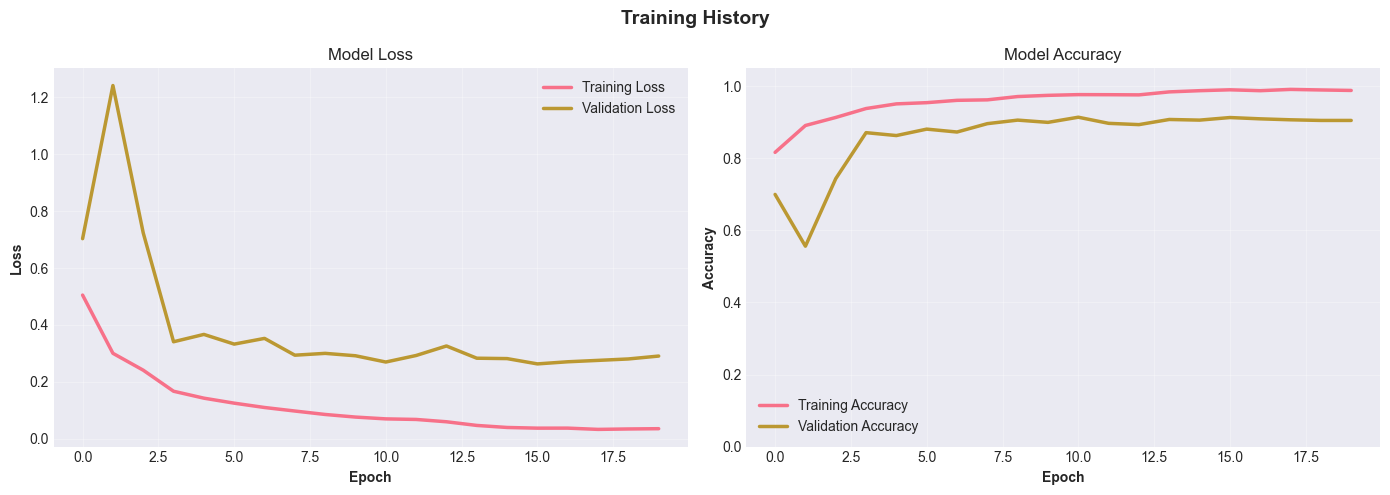

✓ Training history visualized


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2.5)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2.5)
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Loss', fontweight='bold')
axes[0].set_title('Model Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2.5)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5)
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Accuracy', fontweight='bold')
axes[1].set_title('Model Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("✓ Training history visualized")

## 9. Model Evaluation


Evaluating model on test set...

Test Metrics:
  Accuracy:  0.9094
  Precision: 0.9199
  Recall:    0.9094
  F1-Score:  0.9085

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9676    0.7475    0.8434       400
  meningioma     0.7906    0.9625    0.8681       400
     notumor     0.9346    1.0000    0.9662       400
   pituitary     0.9867    0.9275    0.9562       400

    accuracy                         0.9094      1600
   macro avg     0.9199    0.9094    0.9085      1600
weighted avg     0.9199    0.9094    0.9085      1600



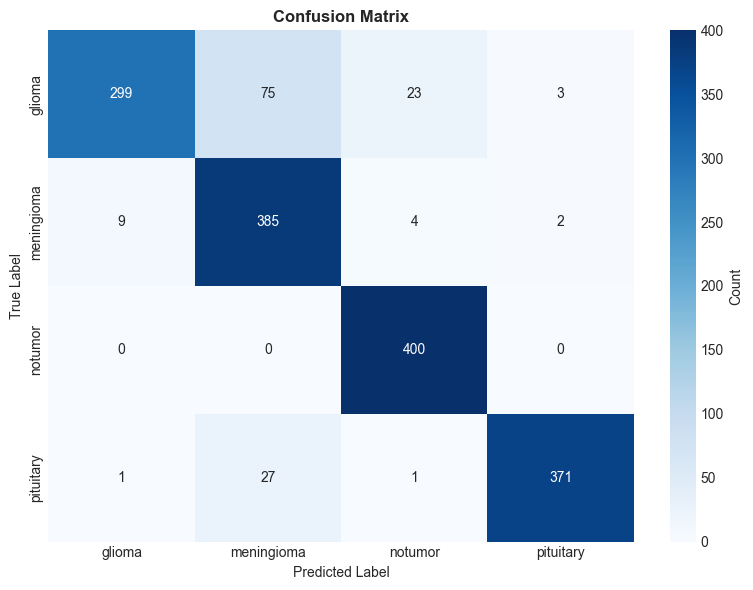

In [9]:
print("\nEvaluating model on test set...")
y_pred_probabilities = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_probabilities, axis=1)

test_accuracy = accuracy_score(y_test, y_pred_classes)
test_precision = precision_score(y_test, y_pred_classes, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_pred_classes, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_pred_classes, average='weighted', zero_division=0)

print(f"\nTest Metrics:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_, digits=4))

conf_matrix = confusion_matrix(y_test, y_pred_classes)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

## 10. Model Trustworthiness Assessment

In [10]:
def calculate_trustworthiness_metrics(y_true, y_pred_classes, y_pred_probs, class_names):
    """Calculate trustworthiness metrics."""
    metrics = {}
    
    max_probs = np.max(y_pred_probs, axis=1)
    avg_confidence = np.mean(max_probs)
    metrics['avg_confidence'] = avg_confidence
    
    epsilon = 1e-10
    entropy = -np.sum(y_pred_probs * np.log(y_pred_probs + epsilon), axis=1)
    avg_entropy = np.mean(entropy)
    metrics['avg_entropy'] = avg_entropy
    
    correct_mask = (y_true == y_pred_classes)
    correct_confidence = max_probs[correct_mask].mean() if correct_mask.sum() > 0 else 0
    incorrect_confidence = max_probs[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0
    metrics['correct_avg_confidence'] = correct_confidence
    metrics['incorrect_avg_confidence'] = incorrect_confidence
    metrics['confidence_gap'] = correct_confidence - incorrect_confidence
    
    class_reliability = {}
    for i, class_name in enumerate(class_names):
        mask = y_true == i
        if mask.sum() > 0:
            class_acc = (y_pred_classes[mask] == y_true[mask]).mean()
            class_confidence = max_probs[mask].mean()
            class_reliability[class_name] = {
                'accuracy': class_acc,
                'avg_confidence': class_confidence,
                'samples': mask.sum()
            }
    metrics['class_reliability'] = class_reliability
    
    overall_accuracy = accuracy_score(y_true, y_pred_classes)
    calibration_score = min(1.0, metrics['confidence_gap'] / 0.5)
    confidence_score = min(1.0, avg_confidence / 0.95)
    entropy_score = max(0, 1.0 - (avg_entropy / 1.4))
    
    trustworthiness_score = (
        0.40 * overall_accuracy +
        0.30 * calibration_score +
        0.20 * confidence_score +
        0.10 * entropy_score
    ) * 100
    
    metrics['overall_trustworthiness_score'] = trustworthiness_score
    return metrics


trustworthiness = calculate_trustworthiness_metrics(y_test, y_pred_classes, y_pred_probabilities, label_encoder.classes_)

print("\n" + "="*70)
print("MODEL TRUSTWORTHINESS ASSESSMENT")
print("="*70)
print(f"\nOverall Trustworthiness Score: {trustworthiness['overall_trustworthiness_score']:.2f}/100")
print(f"\nKey Metrics:")
print(f"  Average Confidence: {trustworthiness['avg_confidence']:.4f}")
print(f"  Prediction Entropy: {trustworthiness['avg_entropy']:.4f}")
print(f"  Confidence-Accuracy Gap: {trustworthiness['confidence_gap']:.4f}")
print(f"\nClass-wise Reliability:")
for class_name, metrics_dict in trustworthiness['class_reliability'].items():
    print(f"\n  {class_name.upper()}:")
    print(f"    Accuracy: {metrics_dict['accuracy']:.4f}")
    print(f"    Avg Confidence: {metrics_dict['avg_confidence']:.4f}")
    print(f"    Samples: {metrics_dict['samples']}")

if trustworthiness['overall_trustworthiness_score'] >= 85:
    print(f"\n✓ HIGHLY TRUSTWORTHY - Model is reliable for deployment")
elif trustworthiness['overall_trustworthiness_score'] >= 75:
    print(f"\n✓ MODERATELY TRUSTWORTHY - Good for most applications")
else:
    print(f"\n⚠ Needs improvement before deployment")


MODEL TRUSTWORTHINESS ASSESSMENT

Overall Trustworthiness Score: 73.00/100

Key Metrics:
  Average Confidence: 0.9606
  Prediction Entropy: 0.1039
  Confidence-Accuracy Gap: 0.1227

Class-wise Reliability:

  GLIOMA:
    Accuracy: 0.7475
    Avg Confidence: 0.9326
    Samples: 400

  MENINGIOMA:
    Accuracy: 0.9625
    Avg Confidence: 0.9582
    Samples: 400

  NOTUMOR:
    Accuracy: 1.0000
    Avg Confidence: 0.9988
    Samples: 400

  PITUITARY:
    Accuracy: 0.9275
    Avg Confidence: 0.9528
    Samples: 400

⚠ Needs improvement before deployment


## 11. LIME Model Explainability


Initializing LIME explainer...

[1/3] Generating LIME explanation...
  True: glioma, Predicted: notumor (confidence: 0.9122)


  0%|          | 0/500 [00:00<?, ?it/s]

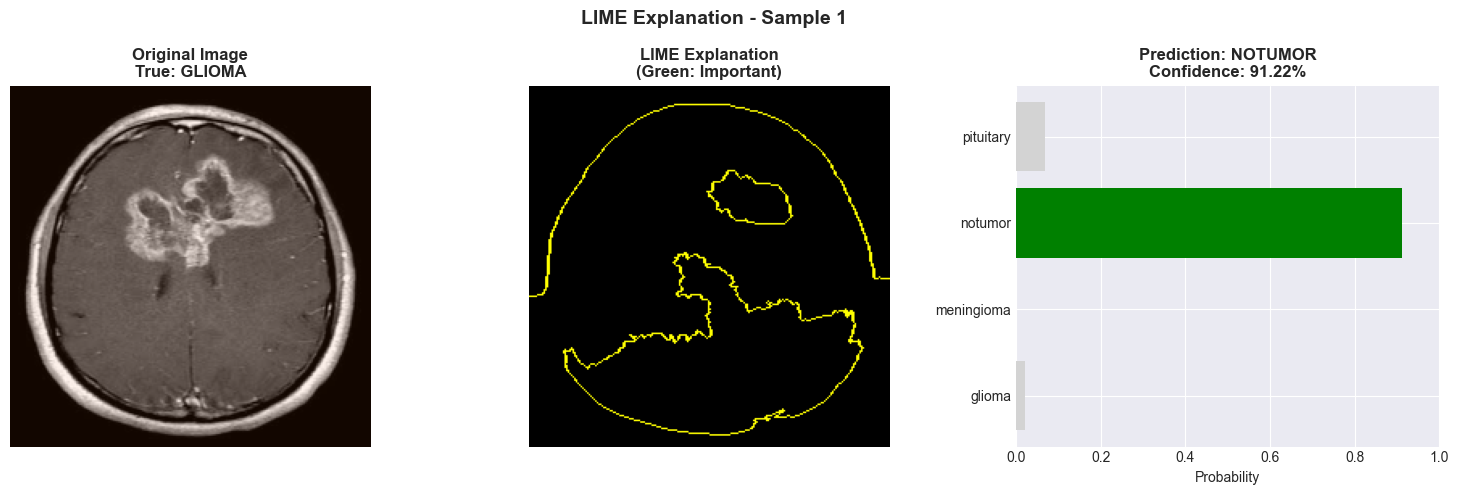


[2/3] Generating LIME explanation...
  True: meningioma, Predicted: meningioma (confidence: 0.9853)


  0%|          | 0/500 [00:00<?, ?it/s]

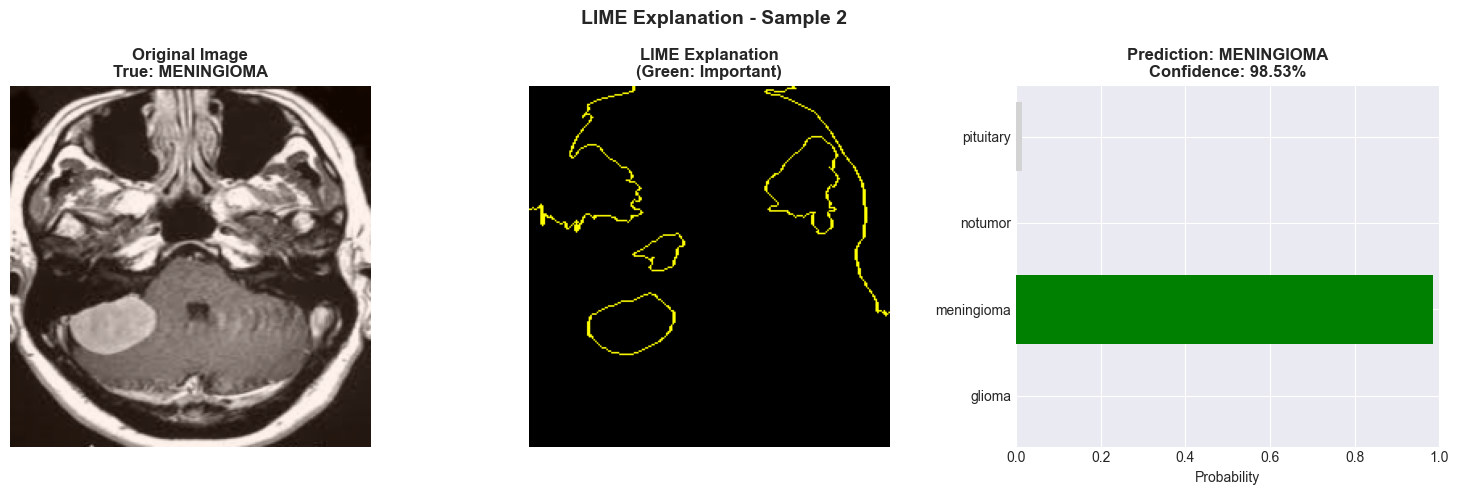


[3/3] Generating LIME explanation...
  True: notumor, Predicted: notumor (confidence: 1.0000)


  0%|          | 0/500 [00:00<?, ?it/s]

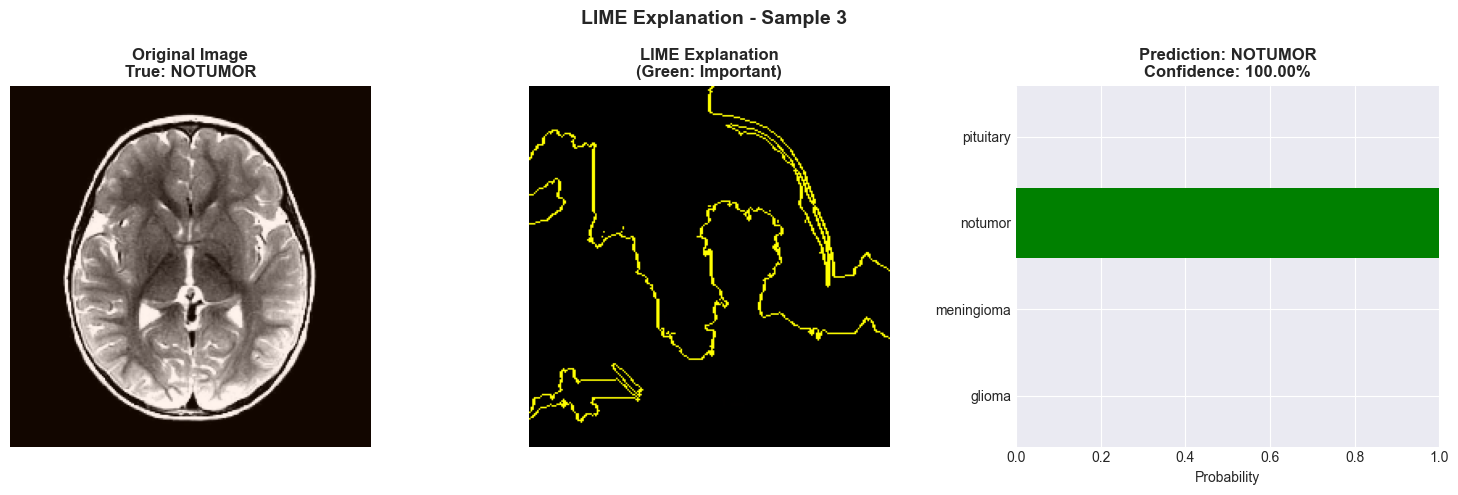


✓ LIME explainability demonstration complete


In [11]:
def predict_fn(images):
    """Prediction function for LIME."""
    images = np.array(images, dtype=np.float32)
    images = preprocess_input(images.copy())
    return model.predict(images, verbose=0)


print("\nInitializing LIME explainer...")
explainer = lime_image.LimeImageExplainer()

samples_to_explain = [0, len(X_test)//3, 2*len(X_test)//3]

for sample_num, sample_idx in enumerate(samples_to_explain, 1):
    sample_img = X_test[sample_idx].copy()
    viz_img = sample_img.copy()
    viz_img = (viz_img - viz_img.min()) / (viz_img.max() - viz_img.min() + 1e-8)
    
    sample_pred_probs = predict_fn(np.expand_dims(sample_img, axis=0))[0]
    sample_pred_idx = np.argmax(sample_pred_probs)
    sample_pred_class = label_encoder.classes_[sample_pred_idx]
    true_class = label_encoder.classes_[y_test[sample_idx]]
    confidence = sample_pred_probs[sample_pred_idx]
    is_correct = (true_class == sample_pred_class)
    
    print(f"\n[{sample_num}/3] Generating LIME explanation...")
    print(f"  True: {true_class}, Predicted: {sample_pred_class} (confidence: {confidence:.4f})")
    
    explanation = explainer.explain_instance(
        viz_img.astype('double'),
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=LIME_NUM_SAMPLES
    )
    
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=LIME_NUM_FEATURES,
        hide_rest=False
    )
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'LIME Explanation - Sample {sample_num}', fontsize=14, fontweight='bold')
    
    axes[0].imshow(viz_img, cmap='gray')
    axes[0].set_title(f'Original Image\nTrue: {true_class.upper()}', fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(mark_boundaries(temp / 255.0, mask))
    axes[1].set_title('LIME Explanation\n(Green: Important)', fontweight='bold')
    axes[1].axis('off')
    
    colors = ['green' if i == sample_pred_idx else 'lightgray' for i in range(NUM_CLASSES)]
    axes[2].barh(label_encoder.classes_, sample_pred_probs, color=colors)
    axes[2].set_xlabel('Probability')
    axes[2].set_title(f'Prediction: {sample_pred_class.upper()}\nConfidence: {confidence:.2%}', fontweight='bold')
    axes[2].set_xlim([0, 1])
    
    plt.tight_layout()
    plt.show()

print(f"\n✓ LIME explainability demonstration complete")

## 12. Summary & Recommendations

In [12]:
PROGRAM_END = time.perf_counter()
total_time = PROGRAM_END - PROGRAM_START

print("\n" + "="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"\nDataset Statistics:")
print(f"  Training samples: {len(X_train)}")
print(f"  Testing samples: {len(X_test)}")
print(f"  Number of classes: {NUM_CLASSES}")
print(f"  Image dimensions: {IMG_SIZE}x{IMG_SIZE}x{IMG_CHANNELS}")

print(f"\nModel Architecture:")
print(f"  Base Model: ResNet50 (ImageNet pre-trained)")
print(f"  Transfer Learning: Yes (frozen base)")
print(f"  Custom Layers: GlobalAvgPool → Dense(512) → Dense(256) → Dense(4)")
print(f"  Total Parameters: {model.count_params():,}")

print(f"\nTraining Results:")
print(f"  Epochs Trained: {actual_epochs}")
print(f"  Training Time: {training_time:.2f} seconds")
print(f"  Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

print(f"\nTest Performance:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")

print(f"\nTrustworthiness Score: {trustworthiness['overall_trustworthiness_score']:.2f}/100")

print(f"\nExecution Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")

print(f"\n" + "="*70)
print("✨ PROJECT COMPLETE")
print("="*70)


PROJECT SUMMARY

Dataset Statistics:
  Training samples: 5600
  Testing samples: 1600
  Number of classes: 4
  Image dimensions: 224x224x3

Model Architecture:
  Base Model: ResNet50 (ImageNet pre-trained)
  Transfer Learning: Yes (frozen base)
  Custom Layers: GlobalAvgPool → Dense(512) → Dense(256) → Dense(4)
  Total Parameters: 24,772,228

Training Results:
  Epochs Trained: 20
  Training Time: 4340.30 seconds
  Final Validation Accuracy: 0.9054

Test Performance:
  Accuracy: 0.9094
  Precision: 0.9199
  Recall: 0.9094
  F1-Score: 0.9085

Trustworthiness Score: 73.00/100

Execution Time: 4502.99 seconds (75.05 minutes)

✨ PROJECT COMPLETE


## 13. Save Model & Artifacts

In [13]:
print("\nSaving model and artifacts...")

model.save(FINAL_MODEL_PATH)
print(f"✅ Model saved: {FINAL_MODEL_PATH}")

with open(LABEL_ENCODER_PATH, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"✅ Label encoder saved: {LABEL_ENCODER_PATH}")

config_data = {
    'classes': CLASSES,
    'img_size': IMG_SIZE,
    'test_accuracy': float(test_accuracy),
    'trustworthiness_score': float(trustworthiness['overall_trustworthiness_score']),
    'training_epochs': int(actual_epochs)
}

with open('model_config.pkl', 'wb') as f:
    pickle.dump(config_data, f)
print(f"✅ Configuration saved: model_config.pkl")

print(f"\n✨ All artifacts saved successfully!")


Saving model and artifacts...
✅ Model saved: brain_tumor_classifier_resnet50.h5
✅ Label encoder saved: label_encoder.pkl
✅ Configuration saved: model_config.pkl

✨ All artifacts saved successfully!
